# Paper 2 — Goal 1 publication figures — FINAL v1.2

**Purpose.** This is a figure-only post-processing notebook for the completed Goal 1 analysis.

It does **not** fit models, rerun cross-validation, recompute bootstrap confidence intervals, or rerun permutation tests. It reads the governed machine-readable outputs produced by Notebook 10B and rebuilds the Goal 1 publication figures using the same restrained scientific visual system used for the final Goal 2 figures.

The main scientific question remains:

> **Does the recording-quality representation Q contain reproducible clinical information in unseen participants?**

The notebook produces:

- **Figure 2** — diagnosis and bulbar-severity information availability, with the two formal permutation nulls;
- **G1 Supplement 01** — cohort/analysis flow;
- **G1 Supplement 02** — Core-Q feature availability;
- **G1 Supplement 03** — native diagnosis calibration;
- **G1 Supplement 04** — bulbar prediction and residual structure;
- **G1 Supplement 05** — prespecified Goal 1 sensitivities;
- **G1 Supplement 06** — descriptive Q–age associations.

### Important statistical distinction

Primary model performance uses the frozen **5-fold × 10-repeat** cross-validation analysis. The formal permutation tests use the validated matched **5-fold × 3-repeat** statistic with 1,000 permutations. Therefore, the model-ladder panels display the primary 10-repeat estimates, whereas the null-distribution panels mark the matched 3-repeat observed statistic used by the corresponding permutation test.

### Supplement numbering

The supplementary filenames use internal Goal 1 identifiers (`FigureS_G1_01`, etc.). Final manuscript-wide Supplementary Figure numbers should be assigned only when Goal 1, Goal 2, and Goal 3 figures are assembled together, because Goal 2 already has its own frozen supplementary figure labels.

### Run instruction

Use **Kernel → Restart Kernel and Run All Cells**.

Outputs are written to:

`outputs/goal1/FINAL_FIGURES_REVIEW/`

The notebook ends with `PASS_PENDING_VISUAL_REVIEW`. It deliberately does **not** write the final Goal 1 `DONE.json` seal. We will freeze only after visual inspection of the regenerated PNGs.

**v1.0.1 path-contract correction.** The figure notebook now reads the exact canonical `data/processed/participant_table.csv` used by Notebook 10, and reads the two-row finalized permutation summary from `completion_v1_0/tables/goal1_permutation_final_summary.csv`. No statistical result or figure design changed.


**FINAL v1.2:** rebuilt from the accepted Goal-1 numerical outputs with a simpler collision-proof layout. The previous experimental text-overlap audit has been removed because it incorrectly treated ordinary tick labels as canvas violations and prevented the new figures from being written. This version writes to a brand-new output directory so stale figures cannot be mistaken for the regenerated ones. No model, statistic, CI, bootstrap, permutation, or sensitivity result is recomputed.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------------------
# Goal-2-compatible publication visual system
# ---------------------------------------------------------------------
PALETTE = {
    "core": "#203D5B",
    "core_plus_age": "#167C80",
    "QADD": "#3D78A8",
    "QGAIN": "#C67645",
    "QREV": "#52866B",
    "QCHAN": "#846A98",
    "neutral": "#6B7280",
    "mid": "#9CA3AF",
    "light": "#D9DEE5",
    "very_light": "#EEF1F4",
}

MM_TO_IN = 1 / 25.4

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7.4,
    "xtick.labelsize": 6.2,
    "ytick.labelsize": 6.2,
    "legend.fontsize": 6.2,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def clean_ax(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", pad=2)

def panel_label(ax, label):
    ax.text(
        -0.12, 1.04, label,
        transform=ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def atomic_json(payload, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)

def atomic_csv(frame: pd.DataFrame, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(tmp, index=False)
    os.replace(tmp, path)

print("Imports and publication visual system: READY")

Imports and publication visual system: READY


## 1. Locate the Paper 2 repository and authoritative Goal 1 completion state

The authoritative Goal 1 output is expected at:

`outputs/goal1/goal1_complete_v1_1/final`

The notebook accepts an explicit `PAPER2_ROOT` environment variable and otherwise searches upward from the current working directory.

In [2]:
def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        p = Path(override).expanduser().resolve()
        if (p / "outputs" / "goal1").exists():
            return p
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {p}")

    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "outputs" / "goal1").exists() and (p / "data").exists():
            return p

    raise FileNotFoundError(
        "Could not identify the Paper 2 project root. "
        "Run from Paper_2_Leakage/Code or set PAPER2_ROOT."
    )

ROOT = find_project_root()

preferred = ROOT / "outputs" / "goal1" / "goal1_complete_v1_1" / "final"
if preferred.exists():
    OUT = preferred
else:
    candidates = sorted(
        (ROOT / "outputs" / "goal1").glob("goal1_complete*/final"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError("No completed Goal 1 final output directory was found.")
    OUT = candidates[0]

TABLES = OUT / "tables"
COMPLETION = OUT / "completion_v1_0"
FIGURES = ROOT / "outputs" / "goal1" / "FINAL_FIGURES_V1_2"
FIGURE_TABLES = FIGURES / "source_tables"

FIGURES.mkdir(parents=True, exist_ok=True)
FIGURE_TABLES.mkdir(parents=True, exist_ok=True)

COMPLETION_MANIFEST = COMPLETION / "GOAL1_COMPLETION_MANIFEST.json"
if not COMPLETION_MANIFEST.exists():
    raise FileNotFoundError(f"Goal 1 completion manifest missing: {COMPLETION_MANIFEST}")

completion = json.loads(COMPLETION_MANIFEST.read_text(encoding="utf-8"))
if completion.get("status") != "PASS_PENDING_FIGURE_REVIEW":
    raise RuntimeError(
        "This notebook requires the Notebook-10B completion state "
        f"PASS_PENDING_FIGURE_REVIEW; found {completion.get('status')!r}."
    )

print("Paper 2 root:", ROOT)
print("Authoritative Goal 1 output:", OUT)
print("Completion status:", completion["status"])
print("Publication review figure folder:", FIGURES)

Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Authoritative Goal 1 output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\goal1_complete_v1_1\final
Completion status: PASS_PENDING_FIGURE_REVIEW
Publication review figure folder: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\FINAL_FIGURES_V1_2


## 2. Hard source-table gate

Every plotted quantitative result is read from the completed Goal 1 machine-readable outputs. No primary result is hand-entered.

The gate verifies:

- 2,000-bootstrap final confidence intervals;
- 1,000 formal permutations for each task;
- matched 3-repeat permutation statistics;
- canonical OOF predictions;
- complete sensitivity and calibration tables.

In [3]:
SOURCE_FILES = {
    # Notebook 10B final two-row permutation summary used only for Figure-2 annotation.
    "metrics": TABLES / "goal1_metrics.csv",
    "permutation": COMPLETION / "tables" / "goal1_permutation_final_summary.csv",
    "dx_null": TABLES / "diagnosis_coreq_permutation_null.csv",
    "sev_null": TABLES / "severity_coreq_permutation_null.csv",
    "sensitivity": TABLES / "goal1_sensitivity_summary.csv",
    "dx_oof": TABLES / "goal1_dx_oof.csv",
    "sev_oof": TABLES / "goal1_bulbar_oof.csv",
    "calibration_stats": TABLES / "diagnosis_calibration_statistics.csv",
    "calibration_curve": TABLES / "diagnosis_calibration_curve.csv",
    "q_age": TABLES / "descriptive_q_age_associations.csv",
    "availability": TABLES / "figureS2_feature_availability_source.csv",
    "recording_table": ROOT / "data" / "processed" / "recording_table_phase0.csv",
    # Exact canonical participant table used by Notebook 10 / Goal 2.
    "participant_table": ROOT / "data" / "processed" / "participant_table.csv",
    "permutation_amendment": COMPLETION / "audit" / "goal1_permutation_method_amendment.json",
}

missing = [str(p) for p in SOURCE_FILES.values() if not p.exists() or p.stat().st_size == 0]
if missing:
    raise RuntimeError(
        "Cannot build the publication figures. Missing/empty authoritative sources:\n"
        + "\n".join(missing)
    )

metrics = pd.read_csv(SOURCE_FILES["metrics"], low_memory=False)
permutation = pd.read_csv(SOURCE_FILES["permutation"], low_memory=False)
dx_null = pd.read_csv(SOURCE_FILES["dx_null"], low_memory=False)
sev_null = pd.read_csv(SOURCE_FILES["sev_null"], low_memory=False)
sensitivity = pd.read_csv(SOURCE_FILES["sensitivity"], low_memory=False)
dx_oof = pd.read_csv(SOURCE_FILES["dx_oof"], low_memory=False)
sev_oof = pd.read_csv(SOURCE_FILES["sev_oof"], low_memory=False)
calibration_stats = pd.read_csv(SOURCE_FILES["calibration_stats"], low_memory=False)
calibration_curve = pd.read_csv(SOURCE_FILES["calibration_curve"], low_memory=False)
q_age = pd.read_csv(SOURCE_FILES["q_age"], low_memory=False)
availability = pd.read_csv(SOURCE_FILES["availability"], low_memory=False)
recording_table = pd.read_csv(SOURCE_FILES["recording_table"], low_memory=False)
participant_table = pd.read_csv(SOURCE_FILES["participant_table"], low_memory=False)

# Validate final resampling contract.
if "bootstrap_replicates" not in metrics.columns:
    raise RuntimeError("goal1_metrics.csv lacks bootstrap_replicates.")
if int(metrics["bootstrap_replicates"].dropna().min()) != 2000:
    raise RuntimeError("Goal 1 metric CIs are not uniformly from the final 2,000-bootstrap run.")

for task, null in [("diagnosis", dx_null), ("severity", sev_null)]:
    if len(null) != 1000:
        raise RuntimeError(f"{task}: expected 1,000 formal null draws, found {len(null)}.")
    if "null_metric" not in null.columns:
        raise RuntimeError(f"{task}: null table lacks null_metric.")

summary_required = {
    "task", "primary_10_repeat_metric", "matched_3_repeat_observed",
    "null_mean", "null_sd", "extreme_null_draws", "empirical_p",
    "B", "favorable_tail",
}
if not summary_required.issubset(permutation.columns):
    raise RuntimeError(
        "goal1_permutation.csv does not contain the validated final permutation summary columns: "
        + ", ".join(sorted(summary_required - set(permutation.columns)))
    )

for task in ["diagnosis", "severity"]:
    row = permutation.loc[permutation["task"].eq(task)]
    if len(row) != 1:
        raise RuntimeError(f"Expected one final permutation-summary row for {task}; found {len(row)}.")
    if int(row["B"].iloc[0]) != 1000:
        raise RuntimeError(f"{task}: final permutation summary is not B=1000.")

if "bootstrap_replicates" not in sensitivity.columns or not sensitivity["bootstrap_replicates"].eq(2000).all():
    raise RuntimeError("Goal 1 sensitivity CIs are not uniformly 2,000-bootstrap.")

print("AUTHORITATIVE GOAL 1 SOURCE GATE: PASS")
print("Primary CV: 5 folds × 10 repeats")
print("Formal permutation statistic: 5 folds × 3 repeats")
print("Formal permutations per task: 1,000")
print("Bootstrap replicates: 2,000")
display(permutation)

AUTHORITATIVE GOAL 1 SOURCE GATE: PASS
Primary CV: 5 folds × 10 repeats
Formal permutation statistic: 5 folds × 3 repeats
Formal permutations per task: 1,000
Bootstrap replicates: 2,000


,task,primary_10_repeat_metric,matched_3_repeat_observed,null_mean,null_sd,extreme_null_draws,empirical_p,B,favorable_tail
0,diagnosis,0.743038,0.740410,0.487495,0.038132,0,0.000999,1000,upper
1,severity,1.685235,1.680926,2.031577,0.022963,0,0.000999,1000,lower


## 3. Shared labels, family metadata, and export helpers

The visual language is intentionally matched to Goal 2:

- QADD — blue;
- QGAIN — warm ochre;
- QREV — muted green;
- QCHAN — muted violet;
- Core-Q — dark navy;
- age + Core-Q — teal;
- demographic/baseline quantities — neutral gray.

Model-family colors are used to aid interpretation, not to imply statistical significance.

In [4]:
MODEL_ORDER_DX = [
    "Age", "Support-only", "QADD", "QGAIN", "QREV", "QCHAN",
    "Core-Q", "Age + Core-Q", "Core-Q HGB",
]
MODEL_ORDER_SEV = [
    "Mean baseline", "Age", "Support-only", "QADD", "QGAIN", "QREV", "QCHAN",
    "Core-Q", "Age + Core-Q", "Core-Q HGB",
]

MODEL_COLORS = {
    "Mean baseline": PALETTE["mid"],
    "Age": PALETTE["neutral"],
    "Support-only": PALETTE["mid"],
    "QADD": PALETTE["QADD"],
    "QGAIN": PALETTE["QGAIN"],
    "QREV": PALETTE["QREV"],
    "QCHAN": PALETTE["QCHAN"],
    "Core-Q": PALETTE["core"],
    "Age + Core-Q": PALETTE["core_plus_age"],
    "Core-Q HGB": PALETTE["core"],
}

MODEL_MARKERS = {
    "Core-Q HGB": "s",
}

def q_family(feature: str) -> str:
    f = str(feature).lower()
    for fam in ["qadd", "qgain", "qrev", "qchan"]:
        if f.startswith(fam):
            return fam.upper()
    return "OTHER"

def pretty_q_label(q: str) -> str:
    """Human-readable publication label for a frozen Q feature."""
    q0 = str(q)
    direct = {
        "qadd_pause_ac_level_dbfs_median": "Pause level",
        "qadd_pause_level_iqr_db": "Pause variability",
        "qadd_speech_pause_level_contrast_db": "Speech–pause contrast",
        "qadd_speech_pause_level_diff_db_proc": "Speech–pause contrast",
        "qgain_typical_speech_level_dbfs": "Speech level",
        "qgain_within_segment_iqr_db": "Within-segment variability",
        "qgain_between_segment_mad_db": "Between-segment variability",
        "qgain_abs_drift_db_per_min": "Level drift",
        "qgain_rolling_rms_instability_proc": "RMS instability",
        "qrev_srmr_norm": "SRMR",
    }
    if q0 in direct:
        return direct[q0]

    # Frozen QCHAN names used in Paper 2.
    low = q0.lower()
    if "ltas" in low and "distance" in low:
        return "LTAS distance (dB)"
    if "rolloff95" in low:
        return "Rolloff-95 deficit (Hz)"
    if "highband" in low or "high_band" in low:
        return "High-band ratio deficit"
    if "tilt" in low and "oct" in low:
        return "Tilt steepening (dB/oct)"

    label = q0.replace("_proc", "")
    for prefix in ["qchan_", "qadd_", "qgain_", "qrev_"]:
        label = label.replace(prefix, "")
    label = label.replace("_", " ").strip()
    return label[:1].upper() + label[1:]

def ordered_q_features(frame: pd.DataFrame, feature_col="feature"):
    seen = []
    for f in frame[feature_col].astype(str):
        if f not in seen:
            seen.append(f)
    fam_rank = {"QADD": 0, "QGAIN": 1, "QREV": 2, "QCHAN": 3, "OTHER": 9}
    return sorted(seen, key=lambda f: (fam_rank[q_family(f)], seen.index(f)))

def export_figure(fig, stem: str, source_paths: list[Path]):
    """Write vector + high-resolution raster outputs and provenance."""
    outputs = []
    fig.canvas.draw()
    for ext, kwargs in [
        ("pdf", {}),
        ("svg", {}),
        ("png", {"dpi": 600}),
    ]:
        path = FIGURES / f"{stem}.{ext}"
        fig.savefig(
            path,
            bbox_inches="tight",
            pad_inches=0.10,
            facecolor="white",
            **kwargs,
        )
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Figure export failed: {path}")
        outputs.append(path)

    provenance = {
        "stem": stem,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "status": "FINAL_V1_2_REVIEW",
        "source_files": {
            str(Path(p).relative_to(ROOT)): sha256_file(Path(p))
            for p in source_paths
        },
        "outputs": [str(p.relative_to(ROOT)) for p in outputs],
    }
    atomic_json(provenance, FIGURES / f"{stem}.provenance.json")
    return outputs


def exact_metric(task, model, metric):
    z = metrics.loc[
        metrics["task"].eq(task)
        & metrics["model"].eq(model)
        & metrics["metric"].eq(metric)
    ].copy()
    if len(z) != 1:
        raise RuntimeError(
            f"Expected exactly one metric row for {task}/{model}/{metric}; found {len(z)}."
        )
    return z.iloc[0]

def model_label_with_n(model, n):
    return f"{model}  (n={int(n)})"

print("Shared figure metadata: READY")

Shared figure metadata: READY


## 4. Figure 2 — Does Q contain clinical information?

This is the main Goal 1 figure and follows the frozen four-panel scientific structure.

- **A:** diagnosis AUROC model ladder with 95% bootstrap CIs;
- **B:** formal diagnosis permutation null, with the matched 3-repeat observed Core-Q statistic marked;
- **C:** bulbar-severity MAE model ladder with 95% bootstrap CIs;
- **D:** formal severity permutation null, with the matched 3-repeat observed Core-Q statistic marked.

The AUROC = 0.5 line in panel A is the non-discrimination reference. The permutation panels are the inferential null tests; the model ladders show the primary 10-repeat performance.

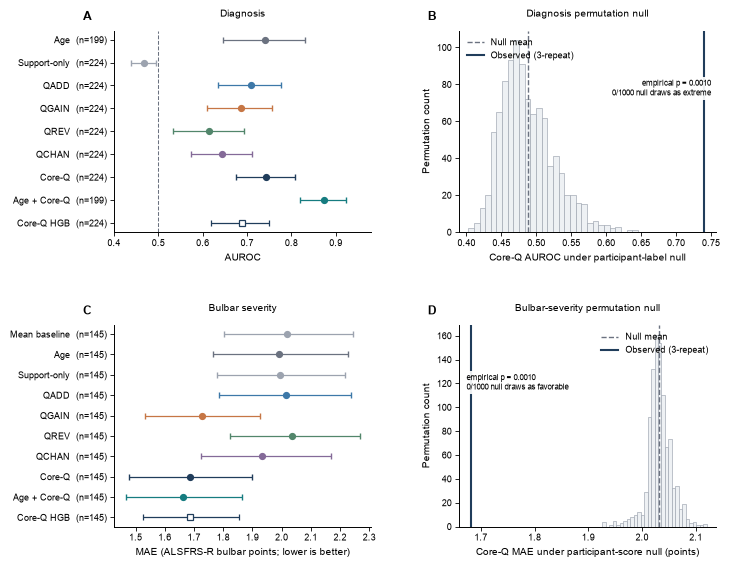

FIGURE 2 FINAL: WRITTEN
C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\FINAL_FIGURES_V1_2\Figure2_Goal1_information_availability_FINAL.png


In [5]:
# Exact source tables for the four main panels.
dx_rows = []
for model in MODEL_ORDER_DX:
    if model in set(metrics.loc[metrics["task"].eq("diagnosis"), "model"]):
        dx_rows.append(exact_metric("diagnosis", model, "AUROC"))
dx_plot = pd.DataFrame(dx_rows)

sev_rows = []
for model in MODEL_ORDER_SEV:
    if model in set(metrics.loc[metrics["task"].eq("severity"), "model"]):
        sev_rows.append(exact_metric("severity", model, "MAE"))
sev_plot = pd.DataFrame(sev_rows)

atomic_csv(dx_plot, FIGURE_TABLES / "Figure2_panelA_diagnosis_ladder.csv")
atomic_csv(sev_plot, FIGURE_TABLES / "Figure2_panelC_severity_ladder.csv")
atomic_csv(dx_null, FIGURE_TABLES / "Figure2_panelB_diagnosis_null.csv")
atomic_csv(sev_null, FIGURE_TABLES / "Figure2_panelD_severity_null.csv")

# A deliberately spacious 2×2 layout. Titles and annotations never share the same
# vertical region, and no free text is placed near axis titles.
fig, axes = plt.subplots(
    2, 2,
    figsize=(190 * MM_TO_IN, 150 * MM_TO_IN),
)
fig.subplots_adjust(
    left=0.18, right=0.985, top=0.94, bottom=0.10,
    wspace=0.34, hspace=0.46,
)

# ---------------- A: diagnosis ladder ----------------
ax = axes[0, 0]
for i, r in dx_plot.reset_index(drop=True).iterrows():
    model = str(r["model"])
    x = float(r["estimate"])
    lo = float(r["ci_low"])
    hi = float(r["ci_high"])
    marker = MODEL_MARKERS.get(model, "o")
    kwargs = dict(
        xerr=[[x-lo], [hi-x]],
        fmt=marker,
        color=MODEL_COLORS[model],
        capsize=2,
        linewidth=0.9,
        markersize=4.2,
        zorder=3,
    )
    if model == "Core-Q HGB":
        kwargs.update(markerfacecolor="white", markeredgecolor=MODEL_COLORS[model], markeredgewidth=0.9)
    ax.errorbar(x, i, **kwargs)

ax.axvline(0.5, color=PALETTE["neutral"], linestyle="--", linewidth=0.75, zorder=0)
ax.set_yticks(np.arange(len(dx_plot)))
ax.set_yticklabels([
    model_label_with_n(r["model"], r["n_participants"])
    for _, r in dx_plot.iterrows()
])
ax.invert_yaxis()
ax.set_xlim(0.40, 0.98)
ax.set_xlabel("AUROC")
ax.set_title("Diagnosis", pad=10)
clean_ax(ax)
panel_label(ax, "A")

# ---------------- B: diagnosis permutation ----------------
ax = axes[0, 1]
null_vals = dx_null["null_metric"].to_numpy(float)
summary_dx = permutation.loc[permutation["task"].eq("diagnosis")].iloc[0]
null_mean = float(summary_dx["null_mean"])
obs_match = float(summary_dx["matched_3_repeat_observed"])
p_emp = float(summary_dx["empirical_p"])
extreme = int(summary_dx["extreme_null_draws"])
B = int(summary_dx["B"])

ax.hist(
    null_vals, bins=30,
    color=PALETTE["very_light"],
    edgecolor=PALETTE["mid"],
    linewidth=0.45,
)
ax.axvline(null_mean, color=PALETTE["neutral"], linestyle="--", linewidth=1.0, label="Null mean")
ax.axvline(obs_match, color=PALETTE["core"], linewidth=1.5, label="Observed (3-repeat)")
xmin = min(float(np.min(null_vals)), obs_match)
xmax = max(float(np.max(null_vals)), obs_match)
span = xmax - xmin
ax.set_xlim(xmin - 0.04*span, xmax + 0.05*span)
ax.set_xlabel("Core-Q AUROC under participant-label null")
ax.set_ylabel("Permutation count")
ax.set_title("Diagnosis permutation null", pad=10)
ax.legend(frameon=False, loc="upper left")
ax.text(
    0.98, 0.76,
    f"empirical p = {p_emp:.4f}\n{extreme}/{B} null draws as extreme",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=6.1,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.5),
)
clean_ax(ax)
panel_label(ax, "B")

# ---------------- C: severity ladder ----------------
ax = axes[1, 0]
for i, r in sev_plot.reset_index(drop=True).iterrows():
    model = str(r["model"])
    x = float(r["estimate"])
    lo = float(r["ci_low"])
    hi = float(r["ci_high"])
    marker = MODEL_MARKERS.get(model, "o")
    kwargs = dict(
        xerr=[[x-lo], [hi-x]],
        fmt=marker,
        color=MODEL_COLORS[model],
        capsize=2,
        linewidth=0.9,
        markersize=4.2,
        zorder=3,
    )
    if model == "Core-Q HGB":
        kwargs.update(markerfacecolor="white", markeredgecolor=MODEL_COLORS[model], markeredgewidth=0.9)
    ax.errorbar(x, i, **kwargs)

ax.set_yticks(np.arange(len(sev_plot)))
ax.set_yticklabels([
    model_label_with_n(r["model"], r["n_participants"])
    for _, r in sev_plot.iterrows()
])
ax.invert_yaxis()
ax.set_xlabel("MAE (ALSFRS-R bulbar points; lower is better)")
ax.set_title("Bulbar severity", pad=10)
clean_ax(ax)
panel_label(ax, "C")

# ---------------- D: severity permutation ----------------
ax = axes[1, 1]
null_vals = sev_null["null_metric"].to_numpy(float)
summary_sev = permutation.loc[permutation["task"].eq("severity")].iloc[0]
null_mean = float(summary_sev["null_mean"])
obs_match = float(summary_sev["matched_3_repeat_observed"])
p_emp = float(summary_sev["empirical_p"])
extreme = int(summary_sev["extreme_null_draws"])
B = int(summary_sev["B"])

ax.hist(
    null_vals, bins=30,
    color=PALETTE["very_light"],
    edgecolor=PALETTE["mid"],
    linewidth=0.45,
)
ax.axvline(null_mean, color=PALETTE["neutral"], linestyle="--", linewidth=1.0, label="Null mean")
ax.axvline(obs_match, color=PALETTE["core"], linewidth=1.5, label="Observed (3-repeat)")
xmin = min(float(np.min(null_vals)), obs_match)
xmax = max(float(np.max(null_vals)), obs_match)
span = xmax - xmin
ax.set_xlim(xmin - 0.05*span, xmax + 0.04*span)
ax.set_xlabel("Core-Q MAE under participant-score null (points)")
ax.set_ylabel("Permutation count")
ax.set_title("Bulbar-severity permutation null", pad=10)
ax.legend(frameon=False, loc="upper right")
ax.text(
    0.03, 0.76,
    f"empirical p = {p_emp:.4f}\n{extreme}/{B} null draws as favorable",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=6.1,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.5),
)
clean_ax(ax)
panel_label(ax, "D")

stem = "Figure2_Goal1_information_availability_FINAL"
export_figure(
    fig, stem,
    [
        SOURCE_FILES["metrics"],
        SOURCE_FILES["dx_null"],
        SOURCE_FILES["sev_null"],
        SOURCE_FILES["permutation"],
        SOURCE_FILES["permutation_amendment"],
    ],
)
plt.show()

print("FIGURE 2 FINAL: WRITTEN")
print(FIGURES / f"{stem}.png")


## 5. G1 Supplement 01 — cohort and analysis flow

The flow figure is deliberately compact. It shows the retained Paper 2 population and the two Goal 1 analysis branches without duplicating detailed data-processing logic already documented elsewhere.

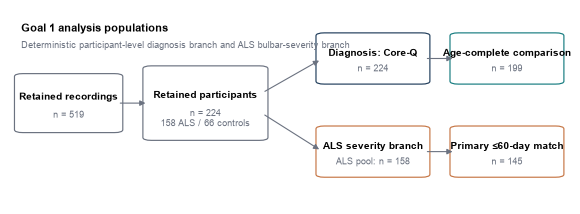

G1 SUPPLEMENT 01: WRITTEN


In [6]:
# Resolve participant identifier and diagnosis labels without hard-coding cohort counts.
pid_col = "participant_id"
if pid_col not in recording_table.columns:
    raise RuntimeError("recording_table_phase0.csv lacks participant_id.")

n_recordings = int(len(recording_table))
n_participants = int(recording_table[pid_col].astype(str).nunique())

# Resolve diagnosis from participant table first, then recording table.
diag_col = None
for candidate in ["diagnosis", "Diagnosis", "dx"]:
    if candidate in participant_table.columns:
        diag_col = candidate
        cohort_source = participant_table
        break
if diag_col is None:
    for candidate in ["diagnosis", "Diagnosis", "dx"]:
        if candidate in recording_table.columns:
            diag_col = candidate
            cohort_source = recording_table.drop_duplicates(pid_col)
            break
if diag_col is None:
    raise RuntimeError("Could not resolve diagnosis column in Phase-0 tables.")

cohort = cohort_source[[pid_col, diag_col]].copy()
cohort[pid_col] = cohort[pid_col].astype(str)
cohort = cohort.drop_duplicates(pid_col)

labels = cohort[diag_col].astype(str).str.upper().str.strip()
n_als = int(labels.eq("ALS").sum())
n_ctrl = int(labels.isin(["CONTROLS", "CONTROL"]).sum())

n_dx_core = int(exact_metric("diagnosis", "Core-Q", "AUROC")["n_participants"])
n_dx_age = int(exact_metric("diagnosis", "Age", "AUROC")["n_participants"])
n_sev = int(exact_metric("severity", "Core-Q", "MAE")["n_participants"])

flow_table = pd.DataFrame([
    {"node": "Retained recordings", "n": n_recordings},
    {"node": "Retained participants", "n": n_participants},
    {"node": "ALS", "n": n_als},
    {"node": "Controls", "n": n_ctrl},
    {"node": "Diagnosis Core-Q", "n": n_dx_core},
    {"node": "Diagnosis age-complete", "n": n_dx_age},
    {"node": "Severity ≤60 d", "n": n_sev},
])
atomic_csv(flow_table, FIGURE_TABLES / "FigureS_G1_01_cohort_flow_source.csv")

if n_participants != n_dx_core:
    raise RuntimeError(
        f"Cohort flow mismatch: retained participants={n_participants}, "
        f"diagnosis Core-Q n={n_dx_core}."
    )

fig, ax = plt.subplots(figsize=(183 * MM_TO_IN, 64 * MM_TO_IN))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def box(x, y, w, h, title, detail, edge, face="white"):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.015",
        linewidth=0.85, edgecolor=edge, facecolor=face,
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h*0.61, title, ha="center", va="center",
            fontsize=7.0, fontweight="bold")
    ax.text(x + w/2, y + h*0.28, detail, ha="center", va="center",
            fontsize=6.2, color=PALETTE["neutral"])
    return patch

def arrow(x0, y0, x1, y1):
    ax.annotate(
        "", xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>", lw=0.8, color=PALETTE["neutral"],
            shrinkA=3, shrinkB=3, mutation_scale=8,
        ),
    )

# Left-to-right scientific flow
box(0.02, 0.38, 0.17, 0.28, "Retained recordings", f"n = {n_recordings}", PALETTE["neutral"])
box(
    0.25, 0.34, 0.20, 0.36,
    "Retained participants",
    f"n = {n_participants}\n{n_als} ALS / {n_ctrl} controls",
    PALETTE["neutral"],
)
arrow(0.19, 0.52, 0.25, 0.52)

# Diagnosis branch
box(
    0.56, 0.63, 0.18, 0.24,
    "Diagnosis: Core-Q",
    f"n = {n_dx_core}",
    PALETTE["core"],
)
box(
    0.80, 0.63, 0.18, 0.24,
    "Age-complete comparison",
    f"n = {n_dx_age}",
    PALETTE["core_plus_age"],
)
arrow(0.45, 0.57, 0.56, 0.75)
arrow(0.74, 0.75, 0.80, 0.75)

# Severity branch
box(
    0.56, 0.15, 0.18, 0.24,
    "ALS severity branch",
    f"ALS pool: n = {n_als}",
    PALETTE["QGAIN"],
)
box(
    0.80, 0.15, 0.18, 0.24,
    "Primary ≤60-day match",
    f"n = {n_sev}",
    PALETTE["QGAIN"],
)
arrow(0.45, 0.47, 0.56, 0.27)
arrow(0.74, 0.27, 0.80, 0.27)

ax.text(
    0.02, 0.93,
    "Goal 1 analysis populations",
    fontsize=7.6, fontweight="bold", va="top",
)
ax.text(
    0.02, 0.84,
    "Deterministic participant-level diagnosis branch and ALS bulbar-severity branch",
    fontsize=6.2, color=PALETTE["neutral"], va="top",
)

stem = "FigureS_G1_01_cohort_flow_FINAL"
export_figure(
    fig, stem,
    [SOURCE_FILES["recording_table"], SOURCE_FILES["participant_table"], SOURCE_FILES["metrics"]],
)
plt.show()

print("G1 SUPPLEMENT 01: WRITTEN")

## 6. G1 Supplement 02 — Core-Q availability

The original participant × feature missingness heatmap is replaced by a direct feature-level availability display. This is more interpretable because Goal 1 needs to show whether each Q measure is empirically supported—not visually enumerate hundreds of mostly redundant participant rows.

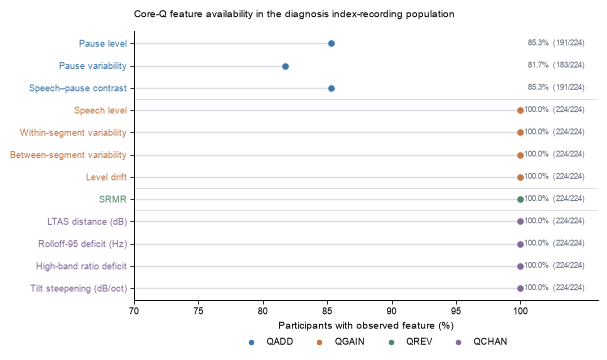

G1 SUPPLEMENT 02 FINAL: WRITTEN


In [7]:
required_av = {"feature", "n_available", "fraction_available"}
if not required_av.issubset(availability.columns):
    raise RuntimeError(
        "Availability source table missing columns: "
        + ", ".join(sorted(required_av - set(availability.columns)))
    )

av = availability.copy()
av["family"] = av["feature"].map(q_family)
av["label"] = av["feature"].map(pretty_q_label)
av["percent_available"] = 100 * pd.to_numeric(av["fraction_available"], errors="raise")
q_order = ordered_q_features(av, "feature")
av["_order"] = av["feature"].map({f: i for i, f in enumerate(q_order)})
av = av.sort_values("_order").reset_index(drop=True)

atomic_csv(av, FIGURE_TABLES / "FigureS_G1_02_CoreQ_availability_source.csv")

fig, ax = plt.subplots(figsize=(190 * MM_TO_IN, 95 * MM_TO_IN))
fig.subplots_adjust(left=0.34, right=0.96, top=0.91, bottom=0.19)

y = np.arange(len(av))
for i, r in av.iterrows():
    fam = r["family"]
    color = PALETTE.get(fam, PALETTE["neutral"])
    x = float(r["percent_available"])
    ax.hlines(i, 70, x, color=PALETTE["light"], linewidth=1.0, zorder=1)
    ax.scatter(x, i, s=28, color=color, edgecolor="white", linewidth=0.5, zorder=3)
    # Separate annotation column at the far right; never overlaps the marker.
    ax.text(
        105.0, i,
        f"{x:.1f}%  ({int(r['n_available'])}/{n_dx_core})",
        fontsize=5.8, va="center", ha="right",
        color=PALETTE["neutral"],
    )

families = av["family"].tolist()
for i in range(len(families)-1):
    if families[i] != families[i+1]:
        ax.axhline(i + 0.5, color=PALETTE["light"], linewidth=0.7, zorder=0)

ax.set_yticks(y)
ax.set_yticklabels(av["label"])
for tick, fam in zip(ax.get_yticklabels(), av["family"]):
    tick.set_color(PALETTE.get(fam, PALETTE["neutral"]))

ax.invert_yaxis()
ax.set_xlim(70, 106)
ax.set_xticks(np.arange(70, 101, 5))
ax.set_xlabel("Participants with observed feature (%)")
ax.set_title("Core-Q feature availability in the diagnosis index-recording population", loc="left", pad=10)
clean_ax(ax)

family_handles = [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=PALETTE[f], markeredgecolor="white",
           markersize=5, label=f)
    for f in ["QADD", "QGAIN", "QREV", "QCHAN"]
    if f in set(av["family"])
]
ax.legend(
    handles=family_handles, frameon=False, ncol=4,
    loc="upper center", bbox_to_anchor=(0.52, -0.11),
)

stem = "FigureS_G1_02_CoreQ_availability_FINAL"
export_figure(fig, stem, [SOURCE_FILES["availability"]])
plt.show()

print("G1 SUPPLEMENT 02 FINAL: WRITTEN")


## 7. G1 Supplement 03 — native diagnosis calibration

Panel A retains the native participant-level cross-fitted calibration curves. Panel B reports the corresponding calibration-intercept and calibration-slope point estimates, with the ideal point at intercept = 0 and slope = 1.

The LOWESS curves are descriptive, particularly at sparsely populated probability extremes.

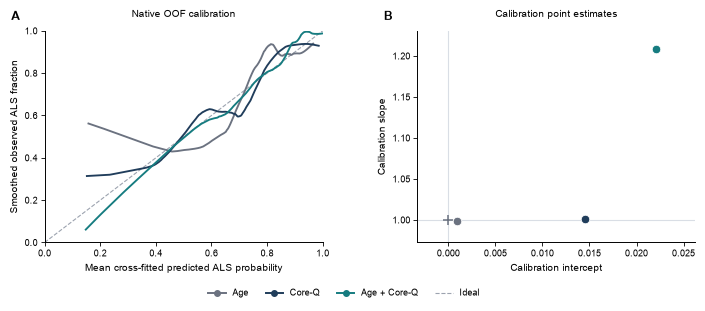

G1 SUPPLEMENT 03 FINAL: WRITTEN


In [8]:
required_curve = {"model", "predicted_probability", "observed_fraction_smooth"}
if not required_curve.issubset(calibration_curve.columns):
    raise RuntimeError(
        "Calibration curve table missing columns: "
        + ", ".join(sorted(required_curve - set(calibration_curve.columns)))
    )

required_stats = {"model", "n_participants", "calibration_intercept", "calibration_slope"}
if not required_stats.issubset(calibration_stats.columns):
    raise RuntimeError(
        "Calibration statistics table missing columns: "
        + ", ".join(sorted(required_stats - set(calibration_stats.columns)))
    )

CAL_MODELS = ["Age", "Core-Q", "Age + Core-Q"]
CAL_COLORS = {
    "Age": PALETTE["neutral"],
    "Core-Q": PALETTE["core"],
    "Age + Core-Q": PALETTE["core_plus_age"],
}
CAL_MARKERS = {"Age": "o", "Core-Q": "o", "Age + Core-Q": "o"}

fig, axes = plt.subplots(
    1, 2,
    figsize=(190 * MM_TO_IN, 84 * MM_TO_IN),
)
fig.subplots_adjust(left=0.10, right=0.97, top=0.88, bottom=0.24, wspace=0.34)

# A
ax = axes[0]
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color=PALETTE["mid"])
for model in CAL_MODELS:
    z = calibration_curve.loc[calibration_curve["model"].eq(model)].sort_values("predicted_probability")
    if z.empty:
        raise RuntimeError(f"Missing calibration curve for {model}.")
    ax.plot(
        z["predicted_probability"], z["observed_fraction_smooth"],
        linewidth=1.35, color=CAL_COLORS[model],
    )
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean cross-fitted predicted ALS probability")
ax.set_ylabel("Smoothed observed ALS fraction")
ax.set_title("Native OOF calibration", pad=10)
clean_ax(ax)
panel_label(ax, "A")

# B — points only; labels are in the shared legend below.
ax = axes[1]
ax.axvline(0, color=PALETTE["light"], linewidth=0.8)
ax.axhline(1, color=PALETTE["light"], linewidth=0.8)
ax.scatter(0, 1, marker="+", s=55, linewidth=1.1, color=PALETTE["neutral"], zorder=2)
for model in CAL_MODELS:
    z = calibration_stats.loc[calibration_stats["model"].eq(model)]
    if len(z) != 1:
        raise RuntimeError(f"Expected one calibration-statistics row for {model}; found {len(z)}.")
    r = z.iloc[0]
    ax.scatter(
        float(r["calibration_intercept"]),
        float(r["calibration_slope"]),
        s=38,
        marker=CAL_MARKERS[model],
        color=CAL_COLORS[model],
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

xs = pd.to_numeric(calibration_stats.loc[calibration_stats["model"].isin(CAL_MODELS), "calibration_intercept"]).to_numpy(float)
ys = pd.to_numeric(calibration_stats.loc[calibration_stats["model"].isin(CAL_MODELS), "calibration_slope"]).to_numpy(float)
xmin, xmax = min(-0.001, xs.min()), max(0.001, xs.max())
ymin, ymax = min(0.99, ys.min()), max(1.01, ys.max())
ax.set_xlim(xmin - 0.10*(xmax-xmin), xmax + 0.18*(xmax-xmin))
ax.set_ylim(ymin - 0.08*(ymax-ymin), ymax + 0.10*(ymax-ymin))
ax.set_xlabel("Calibration intercept")
ax.set_ylabel("Calibration slope")
ax.set_title("Calibration point estimates", pad=10)
clean_ax(ax)
panel_label(ax, "B")

handles = [
    Line2D([0], [0], color=CAL_COLORS[m], lw=1.4, marker="o", markersize=4, label=m)
    for m in CAL_MODELS
] + [
    Line2D([0], [0], color=PALETTE["mid"], lw=0.8, ls="--", label="Ideal")
]
fig.legend(
    handles=handles, frameon=False, ncol=4,
    loc="lower center", bbox_to_anchor=(0.5, 0.05),
)

atomic_csv(calibration_stats, FIGURE_TABLES / "FigureS_G1_03_calibration_statistics.csv")
atomic_csv(calibration_curve, FIGURE_TABLES / "FigureS_G1_03_calibration_curve.csv")

stem = "FigureS_G1_03_diagnosis_calibration_FINAL"
export_figure(
    fig, stem,
    [SOURCE_FILES["calibration_stats"], SOURCE_FILES["calibration_curve"]],
)
plt.show()

print("G1 SUPPLEMENT 03 FINAL: WRITTEN")


## 8. G1 Supplement 04 — bulbar prediction and residual structure

The Core-Q severity model is visualized using its participant-level mean out-of-fold prediction across the 10 repeats.

- **A:** observed versus predicted bulbar score, with identity and score-specific mean prediction ± SE;
- **B:** residual versus observed bulbar score, with score-specific mean residual ± SE.

This figure is diagnostic/descriptive; the primary severity inference remains the held-out MAE and permutation test.

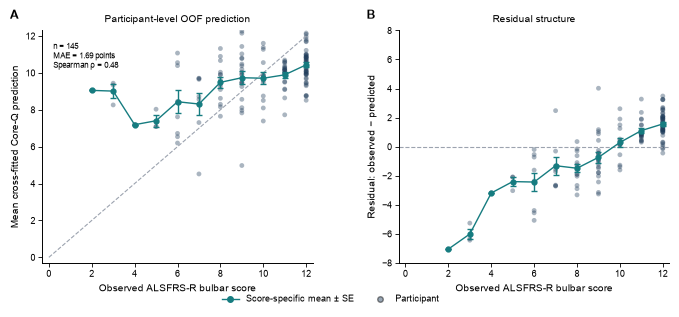

G1 SUPPLEMENT 04: WRITTEN


In [9]:
required_sev_oof = {"participant_id", "model", "true_outcome", "mean_oof_prediction"}
if not required_sev_oof.issubset(sev_oof.columns):
    raise RuntimeError(
        "Severity OOF table missing columns: "
        + ", ".join(sorted(required_sev_oof - set(sev_oof.columns)))
    )

sev = sev_oof.loc[sev_oof["model"].eq("Core-Q")].copy()
if sev.empty:
    raise RuntimeError("Core-Q severity participant OOF rows are missing.")
if not sev["participant_id"].astype(str).is_unique:
    raise RuntimeError("Core-Q severity OOF is not one row per participant.")

sev["observed"] = pd.to_numeric(sev["true_outcome"], errors="raise")
sev["predicted"] = pd.to_numeric(sev["mean_oof_prediction"], errors="raise")
sev["residual"] = sev["observed"] - sev["predicted"]

score_summary = (
    sev.groupby("observed", as_index=False)
    .agg(
        n=("participant_id", "size"),
        mean_prediction=("predicted", "mean"),
        sd_prediction=("predicted", "std"),
        mean_residual=("residual", "mean"),
        sd_residual=("residual", "std"),
    )
)
score_summary["se_prediction"] = score_summary["sd_prediction"] / np.sqrt(score_summary["n"])
score_summary["se_residual"] = score_summary["sd_residual"] / np.sqrt(score_summary["n"])
score_summary[["se_prediction", "se_residual"]] = score_summary[
    ["se_prediction", "se_residual"]
].fillna(0.0)

atomic_csv(sev, FIGURE_TABLES / "FigureS_G1_04_participant_predictions.csv")
atomic_csv(score_summary, FIGURE_TABLES / "FigureS_G1_04_score_summary.csv")

mae_row = exact_metric("severity", "Core-Q", "MAE")
rho_candidates = metrics.loc[
    metrics["task"].eq("severity")
    & metrics["model"].eq("Core-Q")
    & metrics["metric"].eq("Spearman_rho")
]
rho_text = ""
if len(rho_candidates) == 1:
    rho_text = f"\nSpearman ρ = {float(rho_candidates.iloc[0]['estimate']):.2f}"

fig, axes = plt.subplots(
    1, 2,
    figsize=(183 * MM_TO_IN, 82 * MM_TO_IN),
)
fig.subplots_adjust(left=0.10, right=0.97, top=0.90, bottom=0.18, wspace=0.32)

# A
ax = axes[0]
ax.scatter(
    sev["observed"], sev["predicted"],
    s=12, alpha=0.38, color=PALETTE["core"],
    edgecolor="none", zorder=1,
)
ax.plot([0, 12], [0, 12], linestyle="--", linewidth=0.8, color=PALETTE["mid"])
ax.errorbar(
    score_summary["observed"],
    score_summary["mean_prediction"],
    yerr=score_summary["se_prediction"],
    fmt="o-", color=PALETTE["core_plus_age"],
    markersize=3.5, linewidth=1.0, capsize=2, zorder=3,
    label="Score-specific mean ± SE",
)
ax.set_xlim(-0.3, 12.3)
ax.set_ylim(-0.3, 12.3)
ax.set_xticks(np.arange(0, 13, 2))
ax.set_yticks(np.arange(0, 13, 2))
ax.set_xlabel("Observed ALSFRS-R bulbar score")
ax.set_ylabel("Mean cross-fitted Core-Q prediction")
ax.set_title("Participant-level OOF prediction")
ax.text(
    0.04, 0.95,
    f"n = {len(sev)}\nMAE = {float(mae_row['estimate']):.2f} points{rho_text}",
    transform=ax.transAxes, va="top", ha="left", fontsize=6.1,
)
clean_ax(ax)
panel_label(ax, "A")

# B
ax = axes[1]
ax.scatter(
    sev["observed"], sev["residual"],
    s=12, alpha=0.38, color=PALETTE["core"],
    edgecolor="none", zorder=1,
)
ax.axhline(0, linestyle="--", linewidth=0.8, color=PALETTE["mid"])
ax.errorbar(
    score_summary["observed"],
    score_summary["mean_residual"],
    yerr=score_summary["se_residual"],
    fmt="o-", color=PALETTE["core_plus_age"],
    markersize=3.5, linewidth=1.0, capsize=2, zorder=3,
)
lim = max(
    2.0,
    float(np.ceil(np.nanmax(np.abs(sev["residual"])) * 1.1))
)
ax.set_xlim(-0.3, 12.3)
ax.set_ylim(-lim, lim)
ax.set_xticks(np.arange(0, 13, 2))
ax.set_xlabel("Observed ALSFRS-R bulbar score")
ax.set_ylabel("Residual: observed − predicted")
ax.set_title("Residual structure")
clean_ax(ax)
panel_label(ax, "B")

fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color=PALETTE["core_plus_age"], lw=1.0,
               markersize=4, label="Score-specific mean ± SE"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=PALETTE["core"], alpha=0.45, markersize=4,
               label="Participant"),
    ],
    frameon=False, ncol=2,
    loc="lower center", bbox_to_anchor=(0.5, 0.03),
)

stem = "FigureS_G1_04_bulbar_prediction_residuals_FINAL"
export_figure(fig, stem, [SOURCE_FILES["sev_oof"], SOURCE_FILES["metrics"]])
plt.show()

print("G1 SUPPLEMENT 04: WRITTEN")

## 9. G1 Supplement 05 — prespecified sensitivity analyses

The sensitivity figure asks whether the Core-Q conclusion depends on row selection, Q definition, demographic completeness, or model class.

The shaded region is the 95% bootstrap CI of the primary Core-Q analysis. The vertical dark line is the primary point estimate. It is a visual reference, not a null hypothesis test.

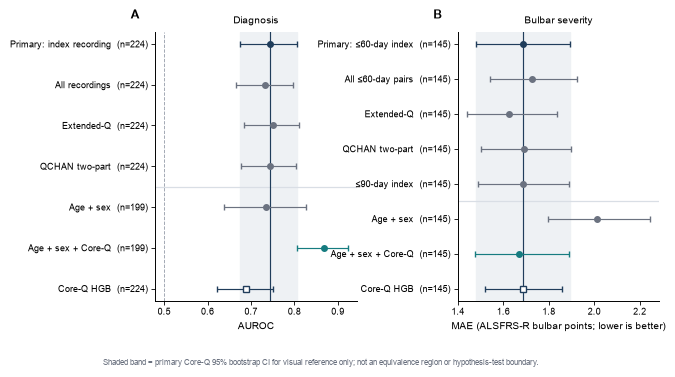

G1 SUPPLEMENT 05: WRITTEN


In [10]:
required_sens = {
    "task", "sensitivity", "metric", "estimate",
    "ci_low", "ci_high", "n_participants",
}
if not required_sens.issubset(sensitivity.columns):
    raise RuntimeError(
        "Sensitivity table missing columns: "
        + ", ".join(sorted(required_sens - set(sensitivity.columns)))
    )

DX_LABELS = {
    "Primary index Core-Q": "Primary: index recording",
    "All recordings, participant-weighted": "All recordings",
    "Extended-Q": "Extended-Q",
    "QCHAN two-part Core-Q": "QCHAN two-part",
    "Age + sex complete-case": "Age + sex",
    "Age + sex + Core-Q complete-case": "Age + sex + Core-Q",
    "Core-Q HGB": "Core-Q HGB",
}
SEV_LABELS = {
    "Primary ≤60 d Core-Q": "Primary: ≤60-day index",
    "All ≤60 d pairs, participant-weighted": "All ≤60-day pairs",
    "Extended-Q": "Extended-Q",
    "QCHAN two-part Core-Q": "QCHAN two-part",
    "≤90 d index Core-Q": "≤90-day index",
    "Age + sex complete-case": "Age + sex",
    "Age + sex + Core-Q complete-case": "Age + sex + Core-Q",
    "Core-Q HGB": "Core-Q HGB",
}

def sensitivity_color(label):
    if "Age + sex + Core-Q" in label:
        return PALETTE["core_plus_age"]
    if "Primary" in label:
        return PALETTE["core"]
    if "HGB" in label:
        return PALETTE["core"]
    return PALETTE["neutral"]

def sensitivity_marker(label):
    return "s" if "HGB" in label else "o"

fig, axes = plt.subplots(
    1, 2,
    figsize=(183 * MM_TO_IN, 102 * MM_TO_IN),
)
fig.subplots_adjust(left=0.27, right=0.97, top=0.89, bottom=0.22, wspace=0.50)

# Diagnosis
ax = axes[0]
d = sensitivity.loc[
    sensitivity["task"].eq("diagnosis")
    & sensitivity["metric"].eq("AUROC")
    & sensitivity["sensitivity"].isin(DX_LABELS)
].copy()
d["_ord"] = d["sensitivity"].map({k: i for i, k in enumerate(DX_LABELS)})
d = d.sort_values("_ord").reset_index(drop=True)
if len(d) != len(DX_LABELS):
    missing_labels = set(DX_LABELS) - set(d["sensitivity"])
    raise RuntimeError(f"Diagnosis sensitivity rows missing: {sorted(missing_labels)}")

primary = d.loc[d["sensitivity"].eq("Primary index Core-Q")].iloc[0]
ax.axvspan(float(primary["ci_low"]), float(primary["ci_high"]),
           color=PALETTE["very_light"], zorder=0)
ax.axvline(float(primary["estimate"]), color=PALETTE["core"], linewidth=0.85, zorder=1)

for i, r in d.iterrows():
    label = DX_LABELS[r["sensitivity"]]
    x = float(r["estimate"]); lo = float(r["ci_low"]); hi = float(r["ci_high"])
    marker = sensitivity_marker(label)
    if marker == "s":
        ax.errorbar(
            x, i, xerr=[[x-lo], [hi-x]], fmt=marker,
            markerfacecolor="white", markeredgecolor=sensitivity_color(label),
            color=sensitivity_color(label), linewidth=0.85, capsize=2,
            markersize=4.0,
        )
    else:
        ax.errorbar(
            x, i, xerr=[[x-lo], [hi-x]], fmt=marker,
            color=sensitivity_color(label), linewidth=0.85, capsize=2,
            markersize=4.0,
        )
# Divider separates robustness/design sensitivities from demographic covariate checks.
if "Age + sex complete-case" in set(d["sensitivity"]):
    idx_demo = int(d.index[d["sensitivity"].eq("Age + sex complete-case")][0])
    ax.axhline(idx_demo - 0.5, color=PALETTE["light"], linewidth=0.9, zorder=0)

ax.set_yticks(np.arange(len(d)))
ax.set_yticklabels([
    f"{DX_LABELS[r['sensitivity']]}  (n={int(r['n_participants'])})"
    for _, r in d.iterrows()
])
ax.invert_yaxis()
ax.axvline(0.5, color=PALETTE["mid"], linestyle="--", linewidth=0.65)
ax.set_xlabel("AUROC")
ax.set_title("Diagnosis")
clean_ax(ax)
panel_label(ax, "A")

# Severity
ax = axes[1]
s = sensitivity.loc[
    sensitivity["task"].eq("severity")
    & sensitivity["metric"].eq("MAE")
    & sensitivity["sensitivity"].isin(SEV_LABELS)
].copy()
s["_ord"] = s["sensitivity"].map({k: i for i, k in enumerate(SEV_LABELS)})
s = s.sort_values("_ord").reset_index(drop=True)
if len(s) != len(SEV_LABELS):
    missing_labels = set(SEV_LABELS) - set(s["sensitivity"])
    raise RuntimeError(f"Severity sensitivity rows missing: {sorted(missing_labels)}")

primary = s.loc[s["sensitivity"].eq("Primary ≤60 d Core-Q")].iloc[0]
ax.axvspan(float(primary["ci_low"]), float(primary["ci_high"]),
           color=PALETTE["very_light"], zorder=0)
ax.axvline(float(primary["estimate"]), color=PALETTE["core"], linewidth=0.85, zorder=1)

for i, r in s.iterrows():
    label = SEV_LABELS[r["sensitivity"]]
    x = float(r["estimate"]); lo = float(r["ci_low"]); hi = float(r["ci_high"])
    marker = sensitivity_marker(label)
    if marker == "s":
        ax.errorbar(
            x, i, xerr=[[x-lo], [hi-x]], fmt=marker,
            markerfacecolor="white", markeredgecolor=sensitivity_color(label),
            color=sensitivity_color(label), linewidth=0.85, capsize=2,
            markersize=4.0,
        )
    else:
        ax.errorbar(
            x, i, xerr=[[x-lo], [hi-x]], fmt=marker,
            color=sensitivity_color(label), linewidth=0.85, capsize=2,
            markersize=4.0,
        )
# Divider separates robustness/design sensitivities from demographic covariate checks.
if "Age + sex complete-case" in set(s["sensitivity"]):
    idx_demo = int(s.index[s["sensitivity"].eq("Age + sex complete-case")][0])
    ax.axhline(idx_demo - 0.5, color=PALETTE["light"], linewidth=0.9, zorder=0)

ax.set_yticks(np.arange(len(s)))
ax.set_yticklabels([
    f"{SEV_LABELS[r['sensitivity']]}  (n={int(r['n_participants'])})"
    for _, r in s.iterrows()
])
ax.invert_yaxis()
ax.set_xlabel("MAE (ALSFRS-R bulbar points; lower is better)")
ax.set_title("Bulbar severity")
clean_ax(ax)
panel_label(ax, "B")

fig.text(
    0.5, 0.055,
    "Shaded band = primary Core-Q 95% bootstrap CI for visual reference only; "
    "not an equivalence region or hypothesis-test boundary.",
    ha="center", va="bottom", fontsize=5.8, color=PALETTE["neutral"],
)

atomic_csv(d, FIGURE_TABLES / "FigureS_G1_05_diagnosis_sensitivities.csv")
atomic_csv(s, FIGURE_TABLES / "FigureS_G1_05_severity_sensitivities.csv")

stem = "FigureS_G1_05_sensitivities_FINAL"
export_figure(fig, stem, [SOURCE_FILES["sensitivity"]])
plt.show()

print("G1 SUPPLEMENT 05: WRITTEN")

## 10. G1 Supplement 06 — descriptive Q–age associations

This is a descriptive audit only. It compares Spearman associations between each Core-Q feature and age:

- across all age-complete participants;
- within age-complete controls.

The figure does not alter the primary endpoint or establish an age-mediated mechanism.

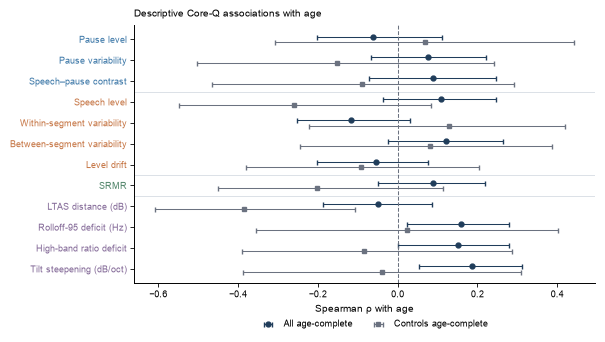

G1 SUPPLEMENT 06: WRITTEN


In [11]:
required_qage = {"feature", "scope", "n", "spearman_rho", "ci_low", "ci_high"}
if not required_qage.issubset(q_age.columns):
    raise RuntimeError(
        "Q-age table missing columns: "
        + ", ".join(sorted(required_qage - set(q_age.columns)))
    )

qa = q_age.copy()
qa["family"] = qa["feature"].map(q_family)
qa["label"] = qa["feature"].map(pretty_q_label)
q_order = ordered_q_features(qa, "feature")

scope_order = ["All age-complete", "Controls age-complete"]
for scope in scope_order:
    if scope not in set(qa["scope"]):
        raise RuntimeError(f"Missing Q-age scope: {scope}")

atomic_csv(qa, FIGURE_TABLES / "FigureS_G1_06_Q_age_source.csv")

fig, ax = plt.subplots(figsize=(183 * MM_TO_IN, 98 * MM_TO_IN))
fig.subplots_adjust(left=0.32, right=0.96, top=0.89, bottom=0.22)

offsets = {"All age-complete": -0.13, "Controls age-complete": 0.13}
colors = {"All age-complete": PALETTE["core"], "Controls age-complete": PALETTE["neutral"]}
markers = {"All age-complete": "o", "Controls age-complete": "s"}

for scope in scope_order:
    z = (
        qa.loc[qa["scope"].eq(scope)]
        .set_index("feature")
        .reindex(q_order)
        .reset_index()
    )
    if z["spearman_rho"].isna().any():
        bad = z.loc[z["spearman_rho"].isna(), "feature"].tolist()
        raise RuntimeError(f"{scope}: missing Q-age effects for {bad}")
    yy = np.arange(len(q_order)) + offsets[scope]
    x = z["spearman_rho"].to_numpy(float)
    lo = z["ci_low"].to_numpy(float)
    hi = z["ci_high"].to_numpy(float)
    ax.errorbar(
        x, yy,
        xerr=np.vstack([x-lo, hi-x]),
        fmt=markers[scope],
        color=colors[scope],
        capsize=1.8, linewidth=0.75, markersize=3.5,
        label=scope,
    )

# Separators and colored labels by Q family.
meta = (
    qa.drop_duplicates("feature")
    .set_index("feature")
    .reindex(q_order)
    .reset_index()
)
families = meta["family"].tolist()
for i in range(len(families)-1):
    if families[i] != families[i+1]:
        ax.axhline(i + 0.5, color=PALETTE["light"], linewidth=0.65)

ax.axvline(0, color=PALETTE["neutral"], linestyle="--", linewidth=0.75)
ax.set_yticks(np.arange(len(q_order)))
ax.set_yticklabels([pretty_q_label(f) for f in q_order])
for tick, fam in zip(ax.get_yticklabels(), families):
    tick.set_color(PALETTE.get(fam, PALETTE["neutral"]))

ax.invert_yaxis()
ax.set_xlabel("Spearman ρ with age")
ax.set_title("Descriptive Core-Q associations with age", loc="left")
ax.legend(
    frameon=False, ncol=2,
    loc="upper center", bbox_to_anchor=(0.52, -0.11),
)
clean_ax(ax)

stem = "FigureS_G1_06_Q_age_descriptive_FINAL"
export_figure(fig, stem, [SOURCE_FILES["q_age"]])
plt.show()

print("G1 SUPPLEMENT 06: WRITTEN")

## 11. Publication-review package audit

This cell verifies that all seven figures exist as PDF, SVG, and 600-dpi PNG, records SHA-256 provenance, and writes a review manifest.

It intentionally stops at `PASS_PENDING_VISUAL_REVIEW`. The final Goal 1 `DONE.json` should be written only after the regenerated figures have been visually inspected.

This FINAL v1.2 run writes uniquely named `*_FINAL` files to `outputs/goal1/FINAL_FIGURES_V1_2/`; therefore older review PNGs cannot be mistaken for the regenerated figures.


In [12]:
FIGURE_STEMS = [
    "Figure2_Goal1_information_availability_FINAL",
    "FigureS_G1_01_cohort_flow_FINAL",
    "FigureS_G1_02_CoreQ_availability_FINAL",
    "FigureS_G1_03_diagnosis_calibration_FINAL",
    "FigureS_G1_04_bulbar_prediction_residuals_FINAL",
    "FigureS_G1_05_sensitivities_FINAL",
    "FigureS_G1_06_Q_age_descriptive_FINAL",
]
inventory_rows = []
for stem in FIGURE_STEMS:
    for ext in ["pdf", "svg", "png"]:
        p = FIGURES / f"{stem}.{ext}"
        inventory_rows.append({
            "stem": stem,
            "format": ext,
            "path": str(p.relative_to(ROOT)),
            "exists": p.exists(),
            "bytes": p.stat().st_size if p.exists() else 0,
            "sha256": sha256_file(p) if p.exists() and p.stat().st_size > 0 else None,
        })

inventory = pd.DataFrame(inventory_rows)
atomic_csv(inventory, FIGURES / "GOAL1_PUBLICATION_FIGURE_INVENTORY_REVIEW.csv")

bad = inventory.loc[~inventory["exists"] | inventory["bytes"].le(0)]
if not bad.empty:
    display(bad)
    raise RuntimeError("At least one Goal 1 publication-review figure artifact is missing or empty.")

source_hashes = {
    str(p.relative_to(ROOT)): sha256_file(p)
    for p in SOURCE_FILES.values()
}

manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "goal": 1,
    "status": "PASS_PENDING_FINAL_VISUAL_CONFIRMATION",
    "engine_version": "goal1-publication-figures-final-v1.2.0",
    "authoritative_goal1_output": str(OUT.relative_to(ROOT)),
    "completion_manifest": str(COMPLETION_MANIFEST.relative_to(ROOT)),
    "completion_manifest_sha256": sha256_file(COMPLETION_MANIFEST),
    "primary_cv": "5 folds x 10 repeats",
    "bootstrap_replicates": 2000,
    "formal_permutations_per_task": 1000,
    "formal_permutation_statistic": "5 folds x 3 repeats",
    "main_figure": FIGURE_STEMS[0],
    "goal1_supplement_internal_ids": FIGURE_STEMS[1:],
    "global_supplement_numbering": "DEFERRED_UNTIL_MANUSCRIPT_ASSEMBLY",
    "figure_directory": str(FIGURES.relative_to(ROOT)),
    "source_hashes": source_hashes,
    "figure_hashes": {
        row["path"]: row["sha256"]
        for _, row in inventory.iterrows()
    },
    "interpretation_boundary": (
        "Goal 1 establishes whether recording-quality characteristics contain reproducible "
        "clinical information in unseen participants. It does not establish technical origin, "
        "causal acquisition effects, confounding, spuriousness, or shortcut learning."
    ),
    "next_step": (
        "Visually inspect the seven publication-review PNG files. If accepted, create the "
        "final Goal 1 figure/freeze seal without changing any statistical result."
    ),
}

atomic_json(manifest, FIGURES / "GOAL1_PUBLICATION_FIGURES_MANIFEST_REVIEW.json")

readme_lines = [
    "Paper 2 — Goal 1 publication figure review package",
    "",
    "Status: PASS_PENDING_VISUAL_REVIEW",
    "",
    "Authoritative numerical state:",
    f"  {OUT}",
    "",
    "Primary performance:",
    "  5 folds x 10 repeats",
    "",
    "Uncertainty:",
    "  2,000 participant bootstrap replicates",
    "",
    "Formal permutation inference:",
    "  1,000 permutations per task",
    "  matched 5-fold x 3-repeat statistic",
    "",
    "Main figure:",
    f"  {FIGURE_STEMS[0]}",
    "",
    "Goal-1 supplementary internal IDs:",
]
readme_lines.extend([f"  {s}" for s in FIGURE_STEMS[1:]])
readme_lines.extend([
    "",
    "Important:",
    "  Global Supplementary Figure numbering is intentionally deferred until manuscript assembly.",
    "  This notebook does not refit models or write the final Goal 1 DONE seal.",
])
(FIGURES / "README_GOAL1_PUBLICATION_FIGURES_REVIEW.txt").write_text(
    "\n".join(readme_lines) + "\n", encoding="utf-8"
)

display(inventory)

print("=" * 78)
print("GOAL 1 PUBLICATION FIGURE PACKAGE: PASS_PENDING_FINAL_VISUAL_CONFIRMATION")
print("=" * 78)
print("Figure folder:", FIGURES)
print("Manifest:", FIGURES / "GOAL1_PUBLICATION_FIGURES_MANIFEST_REVIEW.json")
print()
print("NEXT:")
print("Upload the seven NEW *_FINAL.png files from FINAL_FIGURES_V1_2 for final confirmation.")
print("Do not rerun Goal 1 modeling or permutation notebooks.")

,stem,format,path,exists,bytes,sha256
0,Figure2_Goal1_information_availability_FINAL,pdf,outputs\goal1\FINAL_FIGURES_V1_2\Figure2_Goal1...,True,55162,d66134cd69718c120422e37a90ab070e654e5676d2196b...
1,Figure2_Goal1_information_availability_FINAL,svg,outputs\goal1\FINAL_FIGURES_V1_2\Figure2_Goal1...,True,72450,86a88bdf66bfa1d3054a3206e75fdf9bc9f433aa8949e6...
2,Figure2_Goal1_information_availability_FINAL,png,outputs\goal1\FINAL_FIGURES_V1_2\Figure2_Goal1...,True,532265,76a56b5bc97575510ea7cabf6556bfaee030513f0d532c...
3,FigureS_G1_01_cohort_flow_FINAL,pdf,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_01...,True,47595,d2125d653f78756105c23eca4a916d394127369a24ae93...
4,FigureS_G1_01_cohort_flow_FINAL,svg,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_01...,True,9248,c1b04775982dc168a88ef57ab66bb1241fee7cd197b011...
5,FigureS_G1_01_cohort_flow_FINAL,png,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_01...,True,175768,9ec65eaddc47fada38daeedec6de7e1c5a08756e4cf5fe...
6,FigureS_G1_02_CoreQ_availability_FINAL,pdf,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_02...,True,39533,c322058b0ba7030a71bc0c46273bb4e560a8515d8a0a05...
7,FigureS_G1_02_CoreQ_availability_FINAL,svg,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_02...,True,25130,23e9089b1e2d7329e11ccdf1517d528fde81468684639a...
8,FigureS_G1_02_CoreQ_availability_FINAL,png,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_02...,True,306476,7fddf6f639bdf41c3d481c1e18c82b07fddd6f519a2c52...
9,FigureS_G1_03_diagnosis_calibration_FINAL,pdf,outputs\goal1\FINAL_FIGURES_V1_2\FigureS_G1_03...,True,42538,7b156b4f77600b7b447ff4a0c276458ec5c23af2453cf9...


GOAL 1 PUBLICATION FIGURE PACKAGE: PASS_PENDING_FINAL_VISUAL_CONFIRMATION
Figure folder: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\FINAL_FIGURES_V1_2
Manifest: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\FINAL_FIGURES_V1_2\GOAL1_PUBLICATION_FIGURES_MANIFEST_REVIEW.json

NEXT:
Upload the seven NEW *_FINAL.png files from FINAL_FIGURES_V1_2 for final confirmation.
Do not rerun Goal 1 modeling or permutation notebooks.


## 12. Interpretation guardrail

If the final Goal 1 figure package is accepted, the defensible scientific conclusion is:

> Recording-quality characteristics contain reproducible clinical information in unseen participants, for both ALS/control status and contemporaneous bulbar severity.

The stronger diagnosis performance of age + Core-Q indicates that Q carries diagnostic information beyond the age benchmark in this dataset. The Goal 1 analysis does **not** determine whether the information in Q is technical, biological, behavioral, acquisition-contextual, or a mixture. That distinction is addressed by the downstream Goal 2 and Goal 3 analyses.